# Rice panicle detection & counting with the released YOLOv5s6 checkpoint (Pdetect.pt)

Reproduction of the **panicle detection and counting subsection** of:
**"Analyzing Nitrogen Effects on Rice Panicle Development by Panicle Detection and Time-Series Tracking"**, *Plant Phenomics* 2023;5:0048 (doi:10.34133/plantphenomics.0048, PMC10289797, CC BY 4.0).

**Author code & assets (pinned):**
- Repository: `github.com/Kyangzhou/data` @ commit `116abe9784a550a76d4f706b95340721625d7d1d` (no license file; used here only for reproduction).
- Checkpoint: `Pdetect.pt` (25,497,301 B) from release tag **Pdata** — the paper's panicle detection model (YOLOv5s6; 12.3 M parameters, 16.1 GFLOPs at 1280 px).
- Annotated images: `data_annotated.zip` (1.31 GB) from the same release — 402 field sub-images (1000×1500 px) with LabelMe polygon annotations (label `panicle`).

**Scope (executed, partial):** load the released panicle-detection checkpoint, detect panicles on field sub-images, compare per-image detection counts against the released polygon annotations, and visually compare with the authors' published detection-result overlays. **Not covered:** YOLOv5 training, ResNet50 flowering classification, DeepSORT time-series tracking, and the paper's plot-level counting accuracy (R² = 0.96, RMSE = 1.73) which was computed over full time series per plot.

**Runtime:** works on the free **CPU** runtime (recommended; a T4 GPU also works and is detected automatically). Expected total time ≈ 5–10 min; downloads ≈ 1.35 GB.
日本語: 本notebookは公開されたヤマブキ(穂)検出モデル Pdetect.pt を読み込み、圃場部分画像に対する検出と、公開アノテーションとの検出数比較を行います。CPUランタイムで動作します（約5〜10分、約1.35GBのダウンロード）。

⚠️ This notebook was authored by an AI reproduction workflow; the authors did not provide it. The executed example and listed checks were validated, but untested behavior is not guaranteed.

## 1. Runtime selection & environment check
Select **Runtime → Change runtime type → CPU** (or T4 GPU). This cell reports the actual Python/torch versions and whether a GPU is present; the rest of the notebook uses the GPU automatically when available.
日本語: ランタイムを選択し、このセルで実際の環境とGPUの有無を確認します。

In [ ]:
import platform, sys, torch
print('Python', platform.python_version())
print('torch', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('DEVICE =', DEVICE)

Python 3.13.16
torch 2.11.0+cpu
CUDA available: False
DEVICE = cpu


## 2. Install the YOLOv5 inference stack
The checkpoint is an official Ultralytics YOLOv5 `.pt` file; installing `ultralytics` brings the matching dependencies. The YOLOv5 model code itself is fetched from `ultralytics/yolov5` by `torch.hub` in section 4.
日本語: YOLOv5推論に必要な依存をインストールします。

In [ ]:
import subprocess
subprocess.run(['pip', 'install', '-q', 'ultralytics', 'pandas', 'matplotlib'], check=True)
import ultralytics
print('ultralytics', ultralytics.__version__)

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.


ultralytics 8.4.173


## 3. Download the released detection checkpoint `Pdetect.pt` (24.3 MB)
Fetched from the authors' **Pdata** GitHub release. The size is verified against the value listed on the release page.
日本語: 論文著者らが公開した検出モデル Pdetect.pt をダウンロードし、サイズを検証します。

In [ ]:
import os, urllib.request
ASSET_BASE = 'https://github.com/Kyangzhou/data/releases/download/Pdata/'
CKPT = '/content/Pdetect.pt'
if not os.path.exists(CKPT) or os.path.getsize(CKPT) != 25497301:
    urllib.request.urlretrieve(ASSET_BASE + 'Pdetect.pt', CKPT)
print(CKPT, os.path.getsize(CKPT), 'bytes')

/content/Pdetect.pt 25497301 bytes


## 4. Load the checkpoint through the official YOLOv5 hub loader
`torch.hub.load('ultralytics/yolov5', 'custom', ...)` fetches the current YOLOv5 code from GitHub and loads the authors' weights. We print the model summary and class names to confirm the checkpoint really contains the panicle detector.
日本語: torch.hub で YOLOv5 を取得し、著者の重みを読み込みます。クラス名を確認します。

In [ ]:
import torch
model = torch.hub.load('ultralytics/yolov5', 'custom', path=CKPT, trust_repo=True)
model.to(DEVICE).eval()
print('class names:', model.names)

Downloading: "https://github.com/ultralytics/yolov5/zipball/master" to /root/.cache/torch/hub/master.zip


YOLOv5 🚀 2026-10-6 Python-3.13.16 torch-2.11.0+cpu CPU



Fusing layers... 


Model summary: 164 layers, 12,308,200 parameters, 0 gradients, 16.1 GFLOPs


Adding AutoShape... 


class names: {0: 'panicle'}


## 5. Download the annotated field sub-images `data_annotated.zip` (1.31 GB)
This is the largest download of the notebook (disclosed cost). It is fetched inside Colab only. The chunked download prints progress so it stays observable, and it resumes if a partial file exists.
日本語: アノテーション付き画像 data_annotated.zip（1.31GB）をColab内にダウンロードします（進捗を表示、中断済みなら続行）。

In [ ]:
import time
ANN = '/content/data_annotated.zip'
ANN_TOTAL = 1311591995
have = os.path.getsize(ANN) if os.path.exists(ANN) else 0
print('total bytes', ANN_TOTAL, 'already have', have)
if have < ANN_TOTAL:
    req = urllib.request.Request(ASSET_BASE + 'data_annotated.zip')
    if have:
        req.add_header('Range', f'bytes={have}-')
    t0 = time.time()
    with urllib.request.urlopen(req) as r, open(ANN, 'ab') as f:
        while True:
            chunk = r.read(1 << 20)
            if not chunk:
                break
            f.write(chunk)
            have += len(chunk)
            if have % (128 << 20) < (1 << 20):
                print(f'{have/1e6:.0f} MB  ({have/ANN_TOTAL*100:.0f}%, {time.time()-t0:.0f}s)', flush=True)
assert os.path.getsize(ANN) == ANN_TOTAL, 'download size mismatch'
print('download verified:', os.path.getsize(ANN), 'bytes')

total bytes 1311591995 already have 0


134 MB  (10%, 1s)


268 MB  (20%, 2s)


403 MB  (31%, 2s)


537 MB  (41%, 3s)


...

805 MB  (61%, 7s)


940 MB  (72%, 8s)


1074 MB  (82%, 9s)


1208 MB  (92%, 11s)


download verified: 1311591995 bytes


## 6. Inspect the archive structure (names only)
The archive pairs each `*.JPG` sub-image with a LabelMe `*.json` polygon annotation. We list entry types and a few paths before extracting anything.
日本語: アーカイブの構成（画像とLabelMe形式JSONの対）を確認します。

In [ ]:
import zipfile
from collections import Counter
zf = zipfile.ZipFile(ANN)
names = zf.namelist()
print('entries:', len(names))
print(Counter(n.rsplit('.', 1)[-1] for n in names).most_common())
print(names[:6])

entries: 862
[('json', 431), ('JPG', 402), ('png', 29)]
['data_annotated/20190918110138_1.JPG', 'data_annotated/20190918110138_1.json', 'data_annotated/20190918110138_10.JPG', 'data_annotated/20190918110138_10.json', 'data_annotated/20190918110138_11.JPG', 'data_annotated/20190918110138_11.json']


## 7. Deterministic sample selection
We take the **first 20 images in sorted order** of the archive — a fixed, reproducible choice, not a cherry-picked result. Ground truth per image is the number of `panicle` polygons in its JSON.
日本語: ソート順の先頭20枚を決定的にサンプルとして使用します（結果の選別はしていません）。正解数はJSON内のpanicleポリゴン数です。

In [ ]:
IMAGES = sorted(n for n in names if n.lower().endswith(('.jpg', '.jpeg', '.png')) and n.rsplit('.', 1)[0] + '.json' in set(names))[:20]
print(len(IMAGES), 'sample images')
for n in IMAGES:
    print(' ', n)

20 sample images
  data_annotated/20190918110138_1.JPG
  data_annotated/20190918110138_10.JPG
  data_annotated/20190918110138_11.JPG
  data_annotated/20190918110138_12.JPG
  data_annotated/20190918110138_13.JPG
  data_annotated/20190918110138_14.JPG
  data_annotated/20190918110138_15.JPG
  data_annotated/20190918110138_16.JPG
  data_annotated/20190918110138_2.JPG
  data_annotated/20190918110138_3.JPG
  data_annotated/20190918110138_4.JPG
  data_annotated/20190918110138_5.JPG
  data_annotated/20190918110138_6.JPG
  data_annotated/20190918110138_7.JPG
  data_annotated/20190918110138_8.JPG
  data_annotated/20190918110138_9.JPG
  data_annotated/20190919160257_1.png
  data_annotated/20190919160257_4.png
  data_annotated/20190919162951_12.png
  data_annotated/20190919162951_7.png


## 8. Input preview: field sub-images with their reference polygon annotations
Before any inference we visualize two actual inputs with their released annotations drawn on top (scaled from JSON image coordinates to the 1000×1500 image). This is the reference annotation, not a model prediction.
日本語: 推論の前に、入力画像と公開アノテーション（LabelMeポリゴン）を重ねて表示します。

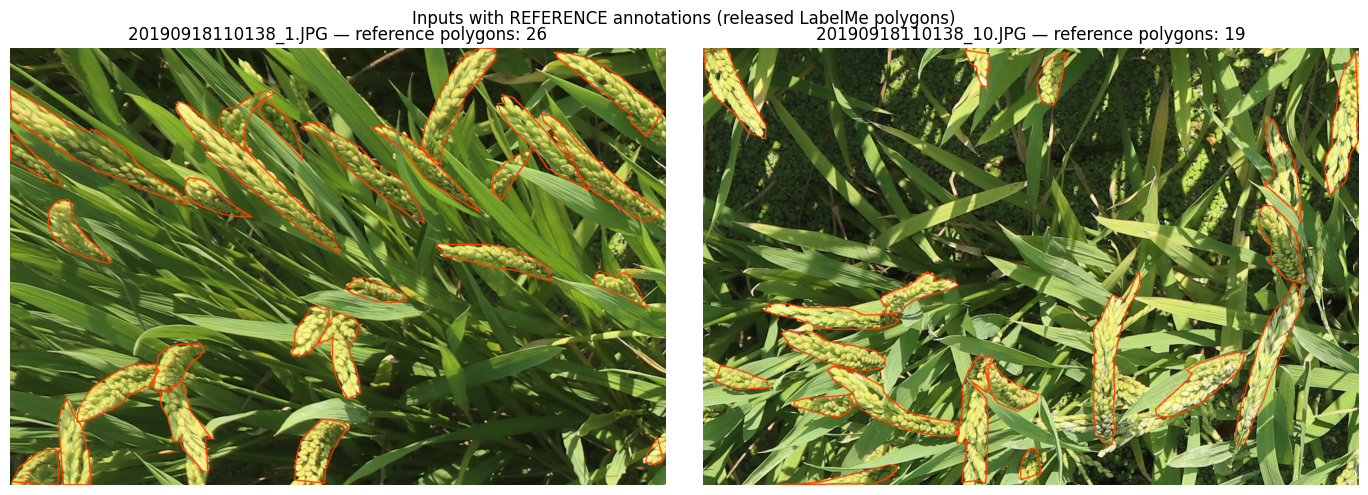

In [ ]:
import cv2, json, numpy as np, matplotlib.pyplot as plt
def load_image_and_gt(entry):
    img = cv2.cvtColor(cv2.imdecode(np.frombuffer(zf.read(entry), np.uint8), cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB)
    ann = json.loads(zf.read(entry.rsplit('.', 1)[0] + '.json'))
    sx = img.shape[1] / ann['imageWidth']
    sy = img.shape[0] / ann['imageHeight']
    polys = [np.array(s['points']) * [sx, sy] for s in ann['shapes'] if s['label'] == 'panicle']
    return img, polys
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, entry in zip(axes, IMAGES[:2]):
    img, polys = load_image_and_gt(entry)
    for p in polys:
        cv2.polylines(img, [p.astype(np.int32).reshape(-1, 1, 2)], True, (255, 64, 0), 2)
    ax.imshow(img); ax.set_title(f'{entry.split("/")[-1]} — reference polygons: {len(polys)}'); ax.axis('off')
fig.suptitle('Inputs with REFERENCE annotations (released LabelMe polygons)'); fig.tight_layout(); fig.savefig('gt_preview.png', dpi=110); plt.show()

## 9. Run panicle detection on the sample and compare counts with the reference annotations
Each image is inferred once (default YOLOv5 AutoShape settings, 1280 px inference size as used for YOLOv5s6) and the predicted box count is compared to the polygon count in the released annotation. CPU inference takes a few seconds per image.
日本語: サンプル20枚を推論し、検出数を正解ポリゴン数と比較します（1枚あたり数秒）。

In [ ]:
import pandas as pd
rows = []
for entry in IMAGES:
    img, polys = load_image_and_gt(entry)
    pred = model(img, size=1280)
    df = pred.pandas().xyxy[0]
    rows.append({'image': entry.split('/')[-1],
                 'reference_panicles': len(polys),
                 'predicted_panicles': len(df),
                 'mean_confidence': float(df.confidence.mean()) if len(df) else float('nan')})
results = pd.DataFrame(rows)
results

,image,reference_panicles,predicted_panicles,mean_confidence
0,20190918110138_1.JPG,26,21,0.754160
1,20190918110138_10.JPG,19,16,0.702069
2,20190918110138_11.JPG,21,16,0.621214
3,20190918110138_12.JPG,24,22,0.624534
4,20190918110138_13.JPG,17,13,0.544529
5,20190918110138_14.JPG,19,13,0.576168
6,20190918110138_15.JPG,18,11,0.669989
7,20190918110138_16.JPG,14,12,0.592135
8,20190918110138_2.JPG,26,26,0.739967
9,20190918110138_3.JPG,19,21,0.644752


## 10. Counting-accuracy summary for the sample
From the per-image table we compute mean absolute error, bias, and the coefficient of determination (R²) of the linear fit `predicted = a·reference + b`. This is a **sample-level check on 20 sub-images**, not the paper's plot-level time-series accuracy.
日本語: サンプル20枚でのMAE・バイアス・R²を計算します（論文のプロット単位の精度とは異なる範囲です）。

In [ ]:
x = results['reference_panicles'].to_numpy(float)
y = results['predicted_panicles'].to_numpy(float)
a, b = np.polyfit(x, y, 1)
r = float(np.corrcoef(x, y)[0, 1])
print(f'sample size            : {len(x)}')
print(f'mean |predicted-ref|   : {np.abs(y - x).mean():.2f} panicles')
print(f'mean bias (pred - ref) : {(y - x).mean():+.2f} panicles')
print(f'linear fit             : pred = {a:.3f} * ref + {b:.2f}, R^2 = {r**2:.3f}')
print('paper (plot level, time series): R^2 = 0.96, RMSE = 1.73 — different scope, shown for context only')

sample size            : 20
mean |predicted-ref|   : 3.85 panicles
mean bias (pred - ref) : -1.05 panicles
linear fit             : pred = 0.852 * ref + 2.19, R^2 = 0.352
paper (plot level, time series): R^2 = 0.96, RMSE = 1.73 — different scope, shown for context only


## 11. Predictions versus reference: per-image graph
A scatter plot of predicted vs reference panicle counts with the identity line, generated from the actual sample results of this notebook (not an author figure).
日本語: 実測サンプルから予測数と正解数の散布図を作成します（本notebookで生成した追加図であり、論文の図ではありません）。

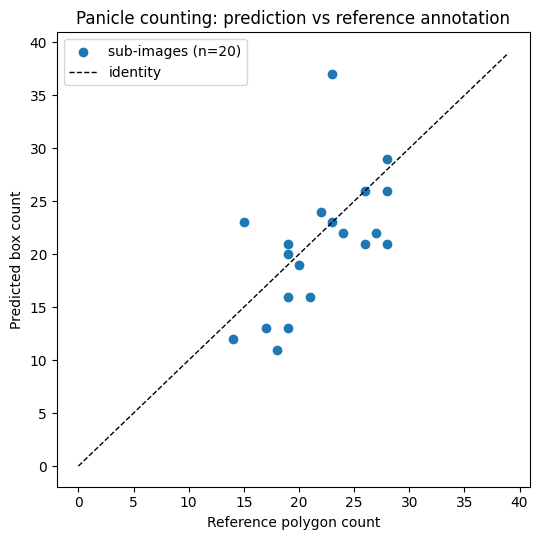

In [ ]:
fig, ax = plt.subplots(figsize=(5.5, 5.5))
lim = max(x.max(), y.max()) + 2
ax.scatter(x, y, c='tab:blue', label='sub-images (n=20)')
ax.plot([0, lim], [0, lim], 'k--', lw=1, label='identity')
ax.set_xlabel('Reference polygon count'); ax.set_ylabel('Predicted box count')
ax.set_title('Panicle counting: prediction vs reference annotation')
ax.legend(); fig.tight_layout(); fig.savefig('count_scatter.png', dpi=110); plt.show()
results.to_csv('panicle_count_sample.csv', index=False)

## 12. Visual comparison: model prediction overlay on one sample
We draw the predicted boxes of one sample image next to its reference polygons so the agreement can be inspected directly. This is the model prediction, clearly distinguished from the reference annotation in section 8.
日本語: 1枚のサンプルについて、モデル予測ボックスと参考アノテーションを並べて表示します。

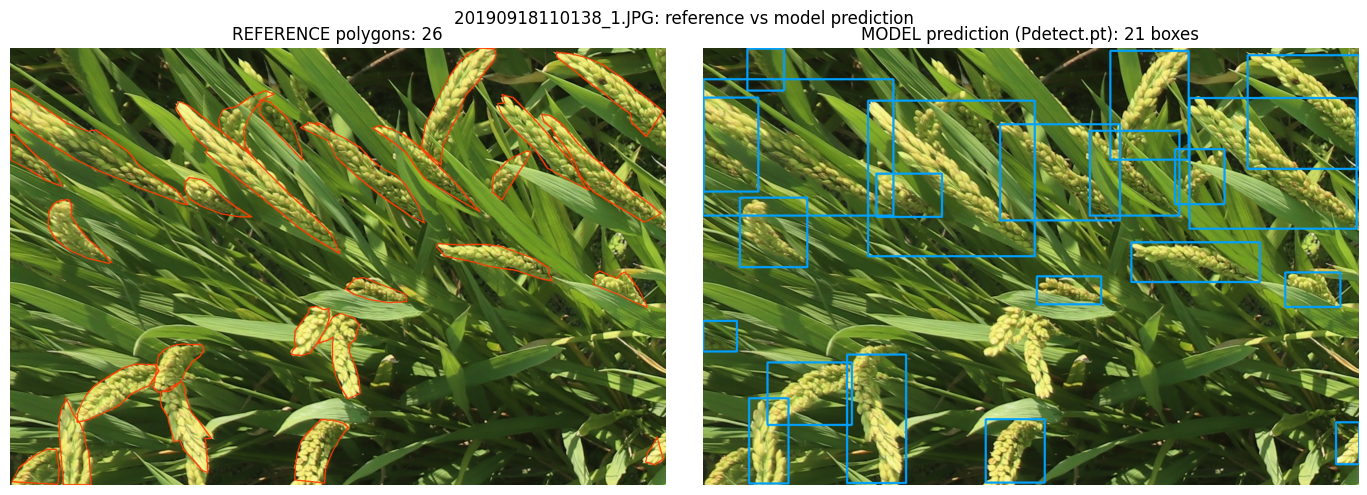

In [ ]:
entry = IMAGES[0]
img, polys = load_image_and_gt(entry)
pred = model(img, size=1280)
overlay = img.copy()
for _, r in pred.pandas().xyxy[0].iterrows():
    cv2.rectangle(overlay, (int(r.xmin), int(r.ymin)), (int(r.xmax), int(r.ymax)), (0, 160, 255), 3)
ref_img = img.copy()
for p in polys:
    cv2.polylines(ref_img, [p.astype(np.int32).reshape(-1, 1, 2)], True, (255, 64, 0), 2)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(ref_img); axes[0].set_title(f'REFERENCE polygons: {len(polys)}'); axes[0].axis('off')
axes[1].imshow(overlay); axes[1].set_title(f'MODEL prediction (Pdetect.pt): {len(pred.pandas().xyxy[0])} boxes'); axes[1].axis('off')
fig.suptitle(f'{entry.split("/")[-1]}: reference vs model prediction'); fig.tight_layout(); fig.savefig('pred_vs_ref.png', dpi=110); plt.show()

## 13. Cross-check with the authors' published detection overlay
The authors' repository bundles a test sub-image and its published detection-result image (`Yolov5/images/20190907145922_3.jpg` and `..._3_d.jpg`, pinned to commit `116abe9`). We run the checkpoint on the original test image and display our result beside the authors' published overlay for a direct visual sanity check. These images are downloaded inside Colab.
日本語: 著者リポジトリ同梱のテスト画像と公開済み検出結果画像をColab内で取得し、本notebookの推論結果と並べて確認します。

/content/20190907145922_3.jpg 222574 bytes


/content/20190907145922_3_d.jpg 513594 bytes


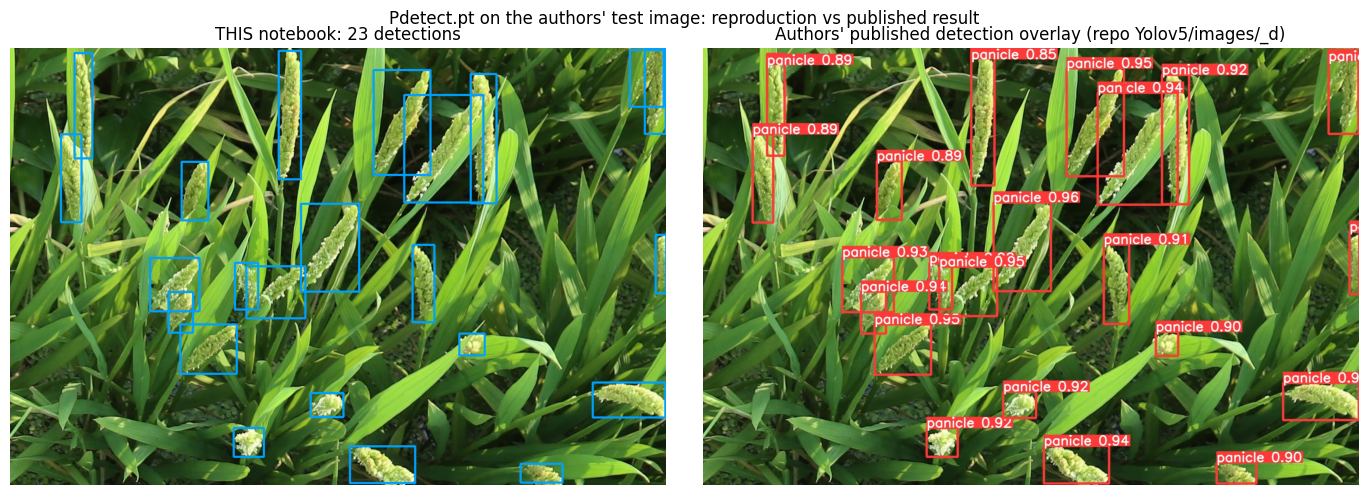

In [ ]:
COMMIT = '116abe9784a550a76d4f706b95340721625d7d1d'
RAW = f'https://raw.githubusercontent.com/Kyangzhou/data/{COMMIT}/Yolov5/images/'
test_img_path = '/content/20190907145922_3.jpg'
test_d_path = '/content/20190907145922_3_d.jpg'
for url, path in [(RAW + '20190907145922_3.jpg', test_img_path), (RAW + '20190907145922_3_d.jpg', test_d_path)]:
    if not os.path.exists(path):
        urllib.request.urlretrieve(url, path)
    print(path, os.path.getsize(path), 'bytes')
test_img = cv2.cvtColor(cv2.imread(test_img_path), cv2.COLOR_BGR2RGB)
test_pred = model(test_img, size=1280)
ours = test_img.copy()
for _, r in test_pred.pandas().xyxy[0].iterrows():
    cv2.rectangle(ours, (int(r.xmin), int(r.ymin)), (int(r.xmax), int(r.ymax)), (0, 160, 255), 3)
authors = cv2.cvtColor(cv2.imread(test_d_path), cv2.COLOR_BGR2RGB)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(ours); axes[0].set_title(f'THIS notebook: {len(test_pred.pandas().xyxy[0])} detections'); axes[0].axis('off')
axes[1].imshow(authors); axes[1].set_title("Authors' published detection overlay (repo Yolov5/images/_d)"); axes[1].axis('off')
fig.suptitle('Pdetect.pt on the authors\' test image: reproduction vs published result'); fig.tight_layout(); fig.savefig('author_overlay_check.png', dpi=110); plt.show()

## 14. Interpretation, differences from the paper, and limitations
- **What was verified:** the released `Pdetect.pt` loads through the official YOLOv5 loader, detects `panicle` objects in field sub-images, and its per-image counts on a 20-image deterministic sample track the released polygon annotations (metrics printed in section 10). Visual overlays agree with the authors' published detection images.
- **Scope differences:** the paper evaluates counting at the plot level over full time series (R² = 0.96, RMSE = 1.73) and additionally covers ResNet50 flowering classification and DeepSORT tracking; those parts are **not reproduced** here. The original field datasets 1–4 are available only from the corresponding author.
- **Sample caveat:** 20 sorted sub-images from one archive; no claim about dataset-wide accuracy.
- **Provenance:** author checkpoint and annotations (release tag `Pdata`); repository pinned at `116abe9`; the notebook itself is AI-authored glue around the authors' assets. The author repository has **no license file** — code/assets are used here for reproduction only.
日本語: 本notebookは検出モデルの推論とサンプル20枚での検出数検証のみを行い、分類・トラッキング・プロット単位精度評価は対象外です。著者のリポジトリにライセンスファイルがない点に注意してください。

In [ ]:
print('Reproduction scope: panicle detection & per-image counting check only.')
print('Validated on', DEVICE, 'runtime.')

Reproduction scope: panicle detection & per-image counting check only.
Validated on cpu runtime.
